# Yolo meet PT-Lightning [deprecated]

Initial attempt but not very successful...

In [1]:
!pip install ultralytics lightning -q


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


## Downlaod the dataset

In [2]:
# ! wget https://www.ultralytics.com/assets/DOTAv1.5.zip
# ! rm -rf DOTAv1.5 sample_data
# ! unzip -qq DOTAv1.5.zip
# ! python -m py_tree DOTAv1.5 -d 1

## Build Pytorch dataset

Create simple dataset with updated OBB annotatiosn

In [3]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image, ImageDraw
from torchvision.transforms import Resize, ToTensor # Import Resize and ToTensor
import math # Import math for coordinate conversion

class DOTADataset(Dataset):
    def __init__(self, data_dir, split='train', transform=None, image_size=(640, 640)):
        """DOTA Dataset.

        Args:
            data_dir (string): Directory with all the images and labels.
            split (string): 'train' or 'val'.
            transform (callable, optional): Optional transform to be applied on a sample.
            image_size (tuple): Desired output size of the image.
        """
        self.data_dir = data_dir
        self.split = split
        self.transform = transform
        self.image_size = image_size
        self.image_dir = os.path.join(data_dir, 'images', split)
        self.label_dir = os.path.join(data_dir, 'labels', split)
        self.image_files = [f for f in os.listdir(self.image_dir) if f.endswith('.png') or f.endswith('.jpg')]
        # Define a default resize transform if no transform is provided
        if self.transform is None:
            self.transform = Resize(self.image_size)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        label_name = img_name.replace('.png', '.txt').replace('.jpg', '.txt')
        label_path = os.path.join(self.label_dir, label_name)
        annotations = self._parse_annotations(label_path)
        sample = {'image': image, 'annotations': annotations}
        if self.transform:
            # Apply the transform to the image
            sample['image'] = self.transform(sample['image'])
            # Note: If using transforms that change bounding box coordinates (like random crop, flip),
            # you would need to apply those transforms to the annotations as well.
            # For simple resizing, normalized coordinates should still be valid.
        return sample

    def _parse_annotations(self, label_path):
        annotations = []
        if not os.path.exists(label_path):
            return annotations
        with open(label_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 9:  # Expecting class index + 8 coordinates
                # Assuming the format is class_index x1 y1 x2 y2 x3 y3 x4 y4 [difficulty]
                try:
                    class_index = int(parts[0]) # Parse class index first
                    coords = [float(p) for p in parts[1:9]] # Parse coordinates
                    annotations.append({'class_index': class_index, 'coords': coords})
                except ValueError:
                    print(f"Skipping malformed line in {label_path}: {line.strip()}")
        return annotations

    @staticmethod
    def convert_obb_coords_to_yolo(coords):
        """Converts 8 xyxyxyxy coordinates to [x_c, y_c, w, h, angle] format."""
        x1, y1, x2, y2, x3, y3, x4, y4 = coords
        # Calculate center (average of all points)
        x_c = (x1 + x2 + x3 + x4) / 4
        y_c = (y1 + y2 + y3 + y4) / 4
        # Calculate distances between opposing vertices
        dist13 = math.sqrt((x1 - x3)**2 + (y1 - y3)**2)
        dist24 = math.sqrt((x2 - x4)**2 + (y2 - y4)**2)
        # Use the maximum of these distances as a measure of the longer side (width)
        # and the minimum as a measure of the shorter side (height).
        # This is still an approximation and might not perfectly match the OBB definition.
        w = max(dist13, dist24)
        h = min(dist13, dist24)
        # Calculate angle (simplified - you might need a more accurate method)
        # Angle calculation from 8 points can be complex for arbitrary orientations.
        # A common approach is to fit a minimum rotated bounding box or use PCA.
        # For a simple approximation, we can use the angle of one of the sides.
        # Let's use the angle of the line from (x1, y1) to (x2, y2)
        angle = math.atan2(y2 - y1, x2 - x1) # Angle in radians
        # Note: The input coords are assumed to be normalized already based on DOTADataset parsing.
        # If not normalized, you would need to normalize them here using image dimensions.
        # x_c /= img_width
        # y_c /= img_height
        # w /= img_width
        # h /= img_height
        return [x_c, y_c, w, h, angle]

    @staticmethod
    def draw_bboxes(image, annotations, color=(255, 0, 0), width=2):
        """Draw bounding boxes on the image.

        Args:
            image (PIL.Image.Image): The image to draw on.
            annotations (list): A list of annotations, where each annotation is a dictionary
                                containing 'coords' (list of 8 floats for x1, y1, ..., x4, y4).
            color (tuple): The color of the bounding box lines (R, G, B).
            width (int): The width of the bounding box lines.

        Returns:
            PIL.Image.Image: The image with bounding boxes drawn.
        """
        draw = ImageDraw.Draw(image)
        for annotation in annotations:
            coords = annotation['coords']
            # The coords are in normalized format, convert them to absolute pixel values
            img_width, img_height = image.size
            abs_coords = [(coords[i] * img_width if i % 2 == 0 else coords[i] * img_height) for i in range(8)]

            # Draw the polygon (bounding box)
            draw.line([(abs_coords[0], abs_coords[1]), (abs_coords[2], abs_coords[3]),
                       (abs_coords[4], abs_coords[5]), (abs_coords[6], abs_coords[7]),
                       (abs_coords[0], abs_coords[1])], fill=color, width=width)
        return image


# Example usage (assuming the dataset is in the /content directory)
dataset = DOTADataset(data_dir='../DOTAv1.5', split='train')
print(f"Number of training samples: {len(dataset)}")
sample = dataset[42]
print("Sample image:", sample['image'])
print("Sample annotations:", sample['annotations'])

# Example of drawing bounding boxes
image_with_bboxes = DOTADataset.draw_bboxes(sample['image'].copy(), sample['annotations'])
image_with_bboxes.show() # This will open the image in a viewer if available

Number of training samples: 1411
Sample image: <PIL.Image.Image image mode=RGB size=640x640 at 0x74C1CDE81D00>
Sample annotations: [{'class_index': 10, 'coords': [0.701823, 0.744792, 0.721354, 0.735677, 0.742188, 0.766927, 0.720052, 0.77474]}, {'class_index': 10, 'coords': [0.761719, 0.72526, 0.765625, 0.707031, 0.813802, 0.716146, 0.809896, 0.733073]}, {'class_index': 9, 'coords': [0.736979, 0.529948, 0.747396, 0.501302, 0.89974, 0.541667, 0.890625, 0.570312]}, {'class_index': 9, 'coords': [0.730469, 0.496094, 0.742188, 0.470052, 0.902344, 0.513021, 0.894531, 0.53776]}, {'class_index': 9, 'coords': [0.734375, 0.464844, 0.742188, 0.436198, 0.895833, 0.473958, 0.888021, 0.501302]}, {'class_index': 9, 'coords': [0.748698, 0.434896, 0.759115, 0.408854, 0.90625, 0.447917, 0.898438, 0.473958]}, {'class_index': 9, 'coords': [0.734375, 0.401042, 0.742188, 0.372396, 0.90625, 0.41276, 0.897135, 0.4375]}, {'class_index': 9, 'coords': [0.748698, 0.371094, 0.757812, 0.342448, 0.910156, 0.380208, 0

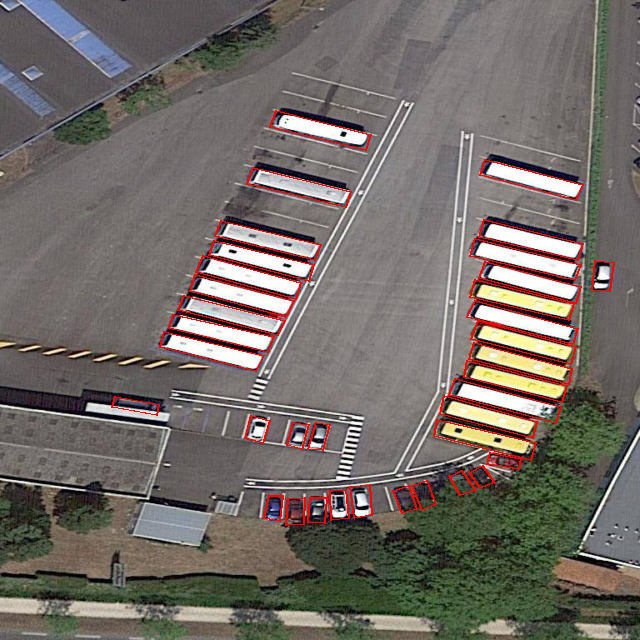

In [4]:
from IPython.display import display

# Example of drawing bounding boxes
image_with_bboxes = DOTADataset.draw_bboxes(sample['image'].copy(), sample['annotations'])

# Display the image inline
display(image_with_bboxes)

## Build Lightning DataModule

In [5]:
from lightning import LightningDataModule # Keep this import style
import torch
from torch.utils.data import DataLoader, random_split # Keep random_split import for now in case it's used elsewhere
from torchvision.transforms import ToTensor, Resize # Import Resize
import numpy as np
import math

# Assuming DOTADataset class is defined in a previous cell

class DOTADataModule(LightningDataModule): # Inherit from LightningDataModule
    def __init__(self, data_dir: str, batch_size: int = 4, num_workers: int = -1):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers if num_workers > 0 else os.cpu_count()
        self.train_dataset = None
        self.val_dataset = None

    def prepare_data(self):
        # Download data if needed. This is called on 1 GPU/TPU in distributed training.
        # It's recommended to do things like downloading data here.
        pass

    def setup(self, stage: str):
        # Assign train/val datasets for use in dataloaders.
        # This is called on every GPU/TPU in distributed training.
        if stage == 'fit' or stage is None:
            self.train_dataset = DOTADataset(data_dir=self.data_dir, split='train')
            self.val_dataset = DOTADataset(data_dir=self.data_dir, split='val')
        # Assign test dataset for use in dataloader(s)
        if stage == 'test' or stage is None:
            self.test_dataset = DOTADataset(data_dir=self.data_dir, split='val')

    def custom_collate_fn(self, batch):
        """Custom collate function to handle images and annotations for Ultralytics YOLO OBB format."""
        images = [item['image'] for item in batch]
        annotations = [item['annotations'] for item in batch]
        # Convert PIL Images to PyTorch tensors
        # Assuming images are all the same size now due to the transform
        images_tensor = torch.stack([ToTensor()(img) for img in images])
        # Process annotations to Ultralytics YOLO OBB format: [class_index, x_center, y_center, width, height, angle]
        # Coordinates should be normalized
        processed_annotations = []
        for img_annotations in annotations:
            img_annotations_processed = []
            for annotation in img_annotations:
                class_index = annotation['class_index']
                coords = annotation['coords'] # Normalized xyxyxyxy
                # Convert xyxyxyxy to [x_c, y_c, w, h, angle] using the static method from DOTADataset
                yolo_obb_coords = DOTADataset.convert_obb_coords_to_yolo(coords)
                # Combine class index and converted coordinates
                img_annotations_processed.append([class_index] + yolo_obb_coords)
            processed_annotations.append(torch.tensor(img_annotations_processed, dtype=torch.float32))
        # Annotations will be a list of tensors, one tensor per image in the batch
        return {'image': images_tensor, 'annotations': processed_annotations}


    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, batch_size=self.batch_size, num_workers=self.num_workers,
            persistent_workers=True, shuffle=True, collate_fn=self.custom_collate_fn
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, batch_size=self.batch_size, num_workers=self.num_workers,
            persistent_workers=True, collate_fn=self.custom_collate_fn
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset, batch_size=self.batch_size, num_workers=self.num_workers,
            persistent_workers=True, collate_fn=self.custom_collate_fn
        )

# Example usage:
data_module = DOTADataModule(data_dir='../DOTAv1.5', batch_size=24)
data_module.setup('fit')
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")

Number of batches in training loader: 59
Number of batches in validation loader: 20


In [ ]:
# Get one batch from the training dataloader
train_batch = next(iter(train_loader))
print("Example Training Batch:")
print("Image batch shape:", train_batch['image'].shape)
print("Annotations batch (first sample):", train_batch['annotations'][0])

# Get one batch from the validation dataloader
val_batch = next(iter(val_loader))
print("Example Validation Batch:")
print("Image batch shape:", val_batch['image'].shape)
print("Annotations batch (first sample):", val_batch['annotations'][0])

## Create Lightning Model

In [7]:
from logging import warning
from lightning import LightningModule
import torch
from ultralytics import YOLO
from ultralytics.utils.loss import v8OBBLoss  # Import v8OBBLoss directly
from dataclasses import dataclass

@dataclass
class Hyp:
    box: float = 1.0
    cls: float = 1.0
    dfl: float = 1.0

class LitYoloObb(LightningModule):
    def __init__(self, model_name='yolo11s-obb.pt', learning_rate=1e-3):
        super().__init__()
        self.automatic_optimization = False
        self.save_hyperparameters()
        # Load the YOLO OBB model and access its underlying PyTorch model
        yolo_model = YOLO(model_name)
        self.model = yolo_model.model  # Access the underlying torch.nn.Module
        # Set args for proper initialization
        self.model.args = yolo_model.args
        self.model.train()
        # Use the existing criterion or reinitialize
        if hasattr(self.model, 'criterion') and self.model.criterion is not None:
            self.criterion = self.model.criterion
        else:
            self.criterion = v8OBBLoss(self.model)
            self.model.criterion = self.criterion
        # Override hyp with dataclass to resolve missing args
        self.criterion.hyp = Hyp()
        self.learning_rate = learning_rate
        # Ensure all parameters require gradients
        self.model.requires_grad_(True)

    def forward(self, x):
        # Forward pass using the underlying PyTorch model
        return self.model(x)

    @staticmethod
    def _move_to_cpu(data):
        """Recursively moves tensors within a nested structure to CPU."""
        if isinstance(data, torch.Tensor):
            return data.to("cpu")
        if isinstance(data, (list, tuple)):
            return type(data)(LitYoloObb._move_to_cpu(item) for item in data)
        if isinstance(data, dict):
            return {key: LitYoloObb._move_to_cpu(value) for key, value in data.items()}
        return data

    def _step(self, batch):
        """Abstracted step logic for training and validation."""
        images = batch['image'].to(self.device)
        annotations = [ann.to("cpu") for ann in batch['annotations']]  # Move list of annotations to CPU

        # Format annotations to a single tensor [batch_index, class_index, x_c, y_c, w, h, angle]
        batched_annotations = []
        for i, img_annotations in enumerate(annotations):
            if img_annotations.numel() > 0:  # Check if there are annotations for this image
                batch_indices = torch.full((img_annotations.shape[0], 1), i, dtype=torch.long)
                batched_annotations.append(torch.cat([batch_indices, img_annotations], dim=1))

        if len(batched_annotations) > 0:
            targets = torch.cat(batched_annotations, dim=0)
        else:
            targets = torch.empty(0, 7, dtype=torch.float32)  # Adjusted to 7 columns

        # Perform a forward pass with the underlying model to get raw predictions
        raw_predictions = self.forward(images)  # Returns raw predictions (e.g., tuple of feature maps for OBB)
        raw_predictions = LitYoloObb._move_to_cpu(raw_predictions)

        # Prepare batch dict for loss computation
        if targets.shape[0] > 0:
            batch_idx = targets[:, 0:1]
            cls_targets = (targets[:, 1:2] - 1).long()  # Convert to 0-based class indices
            bboxes = targets[:, 2:]
        else:
            batch_idx = torch.empty((0, 1), dtype=torch.long)
            cls_targets = torch.empty((0, 1), dtype=torch.long)
            bboxes = torch.empty((0, 5), dtype=torch.float32)

        batch_loss = {
            "batch_idx": batch_idx,
            "cls": cls_targets,
            "bboxes": bboxes,
            "img": images.cpu(),  # Move img to CPU for consistency
        }

        # Compute losses using v8OBBLoss
        # This includes box loss (RotatedBboxLoss), cls loss (BCE), and dfl loss
        total_loss, individual_losses = self.criterion(raw_predictions, batch_loss)

        # Extract individual loss components
        box_loss = individual_losses[0]  # Box loss
        cls_loss = individual_losses[1]  # Class loss
        dfl_loss = individual_losses[2]  # DFL loss

        return raw_predictions, targets, total_loss.sum(), box_loss, cls_loss, dfl_loss

    def training_step(self, batch, batch_idx):
        raw_predictions, targets, total_loss, box_loss, cls_loss, dfl_loss = self._step(batch)
        self.log('train/loss', total_loss, prog_bar=True)
        self.log('train/loss_box', box_loss)
        self.log('train/loss_cls', cls_loss)
        self.log('train/loss_dfl', dfl_loss)

        optimizer = self.configure_optimizers()
        optimizer.zero_grad()
        if total_loss.requires_grad:
            self.manual_backward(total_loss)
        else:
            warning.warning(f"Warning: Loss does not require grad in batch {batch_idx}, skipping backward.")
        optimizer.step()
        return total_loss

    def validation_step(self, batch, batch_idx):
        raw_predictions, targets, total_loss, box_loss, cls_loss, dfl_loss = self._step(batch)
        self.log('val/loss', total_loss, prog_bar=True)
        self.log('val/loss_box', box_loss)
        self.log('val/loss_cls', cls_loss)
        self.log('val/loss_dfl', dfl_loss)
        return total_loss

    def configure_optimizers(self):
        # Define optimizer for the parameters of the underlying PyTorch model
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.learning_rate)
        return optimizer

# Example usage:
model = LitYoloObb()

# Note: Ensure your datamodule provides annotations in [class_index (1-based), x_c, y_c, w, h, angle] normalized format.
# The code will convert class_index to 0-based for the loss computation.


## Train the model with Ligthning

In [ ]:
from lightning import Trainer # Import Trainer
from lightning.pytorch.loggers import CSVLogger # Import CSVLogger

# Logger setup
logger = CSVLogger("../logs", name="yolo_obb_training")

# Trainer setup
# You can adjust max_epochs, gpus/accelerator, etc. as needed
trainer = Trainer(
    devices="auto",
    max_epochs=10,
    precision="bf16-true",
    logger=logger,
)

# Start training
print("Starting training...")
trainer.fit(model, data_module)
print("Training finished.")

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting training...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | model | OBBModel | 9.7 M  | train
-------------------------------------------
9.7 M     Trainable params
0         Non-trainable params
9.7 M     Total params
38.879    Total estimated model params size (MB)
344       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

/home/jirka/.local/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 24. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


...

Validation: |                                                                                                 …

/home/jirka/.local/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Validation: |                                                                                                 …

Validation: |                                                                                                 …


Detected KeyboardInterrupt, attempting graceful shutdown ...
